1)Dataset Upload

In [1]:
from google.colab import files
uploaded = files.upload()


Saving phishing_data.csv to phishing_data.csv


2)Importing Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


3)Loading the Dataset

In [3]:
df = pd.read_csv("phishing_data.csv")
df.head()
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        1781 non-null   object 
 1   URL_LENGTH                 1781 non-null   int64  
 2   NUMBER_SPECIAL_CHARACTERS  1781 non-null   int64  
 3   CHARSET                    1774 non-null   object 
 4   SERVER                     1605 non-null   object 
 5   CONTENT_LENGTH             969 non-null    float64
 6   WHOIS_COUNTRY              1475 non-null   object 
 7   WHOIS_STATEPRO             1419 non-null   object 
 8   WHOIS_REGDATE              1654 non-null   object 
 9   WHOIS_UPDATED_DATE         1642 non-null   object 
 10  TCP_CONVERSATION_EXCHANGE  1781 non-null   int64  
 11  DIST_REMOTE_TCP_PORT       1781 non-null   int64  
 12  REMOTE_IPS                 1781 non-null   int64  
 13  APP_BYTES                  1781 non-null   int64

,0
URL,0
URL_LENGTH,0
NUMBER_SPECIAL_CHARACTERS,0
CHARSET,7
SERVER,176
CONTENT_LENGTH,812
WHOIS_COUNTRY,306
WHOIS_STATEPRO,362
WHOIS_REGDATE,127
WHOIS_UPDATED_DATE,139


4)Encoding Categorical Columns

In [4]:
from sklearn.preprocessing import LabelEncoder

data = df.copy()
label = LabelEncoder()

categorical_cols = ['URL', 'CHARSET', 'SERVER', 'WHOIS_COUNTRY',
                    'WHOIS_STATEPRO', 'WHOIS_REGDATE', 'WHOIS_UPDATED_DATE', 'Type']

for col in categorical_cols:
    data[col] = label.fit_transform(data[col].astype(str))


5)Handling Missing Values

In [5]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(data.drop("Type", axis=1))
y = data["Type"]


6)Train–Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


7)Scaling

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


8)Model Training (SVM only)

In [9]:
from sklearn.svm import SVC

model = SVC(kernel='rbf')
model.fit(X_train, y_train)


SVC()

9)Evaluation (Accuracy, Confusion Matrix)

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Accuracy: 0.988795518207283
Confusion Matrix:
 [[305   1]
 [  3  48]]


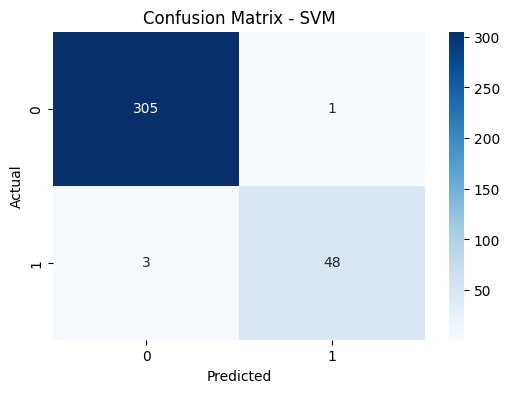

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [12]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       306
           1       0.98      0.94      0.96        51

    accuracy                           0.99       357
   macro avg       0.98      0.97      0.98       357
weighted avg       0.99      0.99      0.99       357



10)Prediction system

In [13]:
def predict_preprocessed(input_features):
    pred = model.predict([input_features])[0]
    return "Phishing" if pred == 1 else "Legitimate"


In [14]:
sample = X_test[0]

print("Prediction:", predict_preprocessed(sample))
print("Actual:", "Phishing" if y_test.iloc[0] == 1 else "Legitimate")


Prediction: Phishing
Actual: Phishing


In [15]:
def predict_website(input_features):

    columns = data.drop("Type", axis=1).columns
    df_input = pd.DataFrame([input_features], columns=columns)

    processed = imputer.transform(df_input)

    processed = scaler.transform(processed)

    pred = model.predict(processed)[0]

    return "Phishing Website" if pred == 1 else "Legitimate Website"



In [16]:
custom_input = [
    16, 7, 3, 8, 263.0, 0, 0, 10, 0,
    0, 2, 700, 9, 10, 1153, 832, 9, 2, 1, 0
]



In [17]:
print("Custom Website Prediction:", predict_website(custom_input))


Custom Website Prediction: Legitimate Website
